In [1]:
### Import what we need for this part
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
### torch.manual_seed(0) fixes the random seed
### This means random numbers will be reproducible
### If you run the code again, you get the same random initialization
###
### This is very useful in teaching and experiments
### because everyone can see the same result

torch.manual_seed(0)

In [ ]:
### Create input data x
### torch.linspace(a,b,n) creates n equally spaced points from a to b
### Here we create 100 points from -pi to pi

x = torch.linspace(-torch.pi, torch.pi, 100) 

In [ ]:
import numpy as np
### Alternatively we could generate data (array) from numpy and switch to torch-type of data
x_np = np.linspace(-np.pi, np.pi, 100) # 生成 100 个点，从 -π 到 π。(100,)

### When our data is in numpy but we want to use a PyTorch model,
### we need to convert the numpy array into a torch tensor
x_torch = torch.tensor(x_np, dtype=torch.float32)

### This means:
###     take the numpy array x_np
###     and convert it into a torch tensor
### dtype=torch.float32 means we want the tensor to use float32 numbers
### This is a very common datatype in neural networks
### Alternative you can use double, or float64


x_np_again = x_torch.numpy()
### This means:
###     take the torch tensor x_torch
###     and convert it back into a numpy array

In [ ]:
### Right now x has shape (100,)
### It is a 1D tensor
###
### But neural network linear layers usually expect a 2D input:
###     (number of samples, number of features)
###
### Since each x value is just one feature,
### we convert x from shape (100,) to shape (100,1)
### by unsqueeze(1)

x = x[:,None] # (100,)变(100, 1)
print("x shape after expansion=", x.shape)

x shape after expansion= torch.Size([100, 1])


In [6]:
### What does unsqueeze(1) mean?
### It adds a new dimension at index 1
###
### Example:
###     before: (100,)
###     after : (100,1)
###
### This is similar to reshape(-1,1) in numpy

In [7]:
### Create target output y = sin(x)
### torch.sin(...) applies sine elementwise

### You could try different kind of functions to train your model
### Try: y = torch.cos(x)
### Try: y = x**2
### Try: y = 3*x**2 - 5*x

y = 3*x**2 - 5*x

print("y shape =", y.shape)

y shape = torch.Size([100, 1])


In [8]:
### Now define the neural network
### nn.Sequential(...) means:
###     stack layers one after another
###
### The model below means:
###     input dimension 1
###     hidden layer with 16 neurons
###     Tanh activation
###     hidden layer with 16 neurons
###     Tanh activation
###     output dimension 1

model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


In [ ]:
### First we define an optimizer
### optimizer means: the method we use to update the parameters in the model
### The model has many trainable parameters, for example:
###     weights
###     biases
### During training, PyTorch will compute the gradient of the loss
### Then the optimizer uses these gradients to update the parameters

### Here we use Adam
### Adam is one of the most commonly used optimizers in deep learning
### It is still based on gradient descent
### but it is smarter than plain gradient descent

### Relation with gradient descent:
### In basic gradient descent, the idea is:
###     parameter = parameter - learning_rate * gradient
### So:
###     1) compute the gradient
###     2) move the parameter in the negative gradient direction
### because that direction usually decreases the loss

### Adam still follows this basic idea:
###     move parameters in the direction that reduces the loss
### But Adam improves gradient descent by adapting the step size (learning_rate) automatically
### for different parameters

optimizer  = torch.optim.Adam(model.parameters(),lr=1e-3) # 这里用 Adam 优化器来更新模型参数。
### model.parameters() means:
### give Adam all trainable parameters inside the model
### so that Adam knows which parameters need to be updated


### Try differet optmizier: Stochastic Gradient Descent
# optimizer  = torch.optim.SGD(model.parameters(),lr=1e-3)


### The word "stochastic" means random
### It is called stochastic gradient descent
### because we usually do not use the whole dataset
### to compute the gradient at every step

### Instead, we often use:
###     one data point
### or
###     a small batch of data points

### So each update is based on only part of the data
### not the full dataset

### Because the update is based on a random sample
### or a random mini-batch,
### the gradient is not exactly the full gradient
### It is a noisy estimate of the full gradient

### That is why it is called "stochastic" gradient descent

### Even though each step is a bit noisy,
### the method is still very useful
### because it is much cheaper than using the whole dataset every ti

In [ ]:
### Now we start the training loop
### epoch means:
### one full pass over the training data
### Here we repeat the training process 1000 times

for epoch in range(1000):

    ### model.train() tells PyTorch that the model is now in training mode
    model.train()

    ### Before computing new gradients,
    ### we first clear the old gradients stored in the model
    ### Why?
    ### Because in PyTorch, gradients are accumulated by default
    ### This means:
    ###     if we do not clear them,
    ###     the new gradient will be added to the previous gradient
    ### Usually this is not what we want in ordinary training
    optimizer.zero_grad() # 清空旧梯度

    ### Forward pass:
    ### send the input x into the model
    ### and get the prediction output
    ### This is exactly the step:
    ###     x  --->  model  --->  output
    output = model(x) # 前向传播

    ### Compute the loss
    ### Here we use mean squared error:
    ###     loss = mean((output - y)^2)
    ### This measures how far the prediction is from the true target y
    ### If output is close to y, loss will be small
    ### If output is far from y, loss will be large
    loss = torch.mean((output - y)**2) # 计算损失

    ### Backward pass:
    ### compute gradients of loss with respect to all trainable parameters
    ### In other words, PyTorch now asks:
    ###     "for each parameter, if I change it a little bit,
    ###      how will the loss change?"
    ### These gradients are stored in parameter.grad
    loss.backward()

    ### Update step:
    ### now the optimizer uses the gradients to update the parameters
    ###  parameter = parameter - learning_rate * gradient
    optimizer.step() # 更新参数

    ### loss.item() converts the PyTorch scalar tensor into a Python number
    ### This makes it easier to print
    print("loss = ", loss.item())

loss =  266.4546203613281
loss =  266.18109130859375
loss =  265.9069519042969
loss =  265.63128662109375
loss =  265.3546447753906
loss =  265.0762634277344
loss =  264.7963562011719
loss =  264.5151672363281
loss =  264.2322692871094
loss =  263.9478454589844
loss =  263.6619873046875
loss =  263.3739929199219
loss =  263.084228515625
loss =  262.7925720214844
loss =  262.4984130859375
loss =  262.2021484375
loss =  261.9031677246094
loss =  261.6011962890625
loss =  261.29620361328125
loss =  260.98760986328125
loss =  260.6752624511719
loss =  260.3583679199219
loss =  260.03692626953125
loss =  259.7100524902344
loss =  259.3768615722656
loss =  259.035400390625
loss =  258.68865966796875
loss =  258.33758544921875
loss =  257.9826965332031
loss =  257.62353515625
loss =  257.26019287109375
loss =  256.89251708984375
loss =  256.5205078125
loss =  256.1441345214844
loss =  255.76303100585938
loss =  255.3773193359375
loss =  254.98687744140625
loss =  254.5913543701172
loss =  254

In [ ]:
### model.eval() puts the model into evaluation mode
### This matters especially for layers like dropout and batch normalization
### In this small model, there is no dropout or batchnorm, so this is optional
### but calling eval() is still good practice before evaluation
model.eval() # 切换到评估模式

with torch.no_grad():
    y_pred = model(x)

print("y_pred shape =", y_pred.shape)
### with torch.no_grad():
### means PyTorch will not track gradients inside this block
###
### Why is this useful?
###     1) saves memory
###     2) faster for pure prediction
###     3) we are not training here, so gradients are unnecessary
###
### Then y_pred is the forward prediction of the model

y_pred shape = torch.Size([100, 1])


In [12]:
### Compute mean squared error by hand
### (y_pred - y)**2 gives squared error for each point
### torch.mean(...) takes the average

mse = torch.mean((y_pred - y) ** 2)
print("MSE =", mse.item())

MSE = 1.9999969005584717


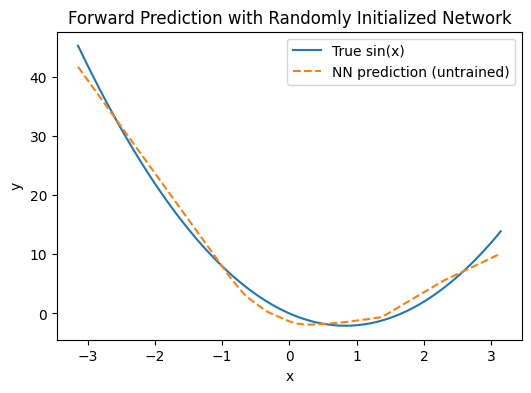

In [13]:
### Visualize the true function and the network prediction
plt.figure(figsize=(6,4))
plt.plot(x.numpy(), y.numpy(), label='True sin(x)')
plt.plot(x.numpy(), y_pred.numpy(),'--', label='NN prediction (untrained)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Forward Prediction with Randomly Initialized Network')
plt.legend()
plt.show()


In [14]:
### When to use detach()?

### In PyTorch, if a tensor is part of the computation graph,
### then PyTorch remembers how it was created
### so that it can later compute gradients by backpropagation

### But sometimes we only want the numerical values
### and we do not want PyTorch to track gradients anymore

### In that case, we use:
###     x_detached = x.detach()

### After detach():
###     1) the values stay the same
###     2) but the new tensor is no longer connected to the old computation graph

### This is useful when:
###     - we want to convert a tensor to numpy
###     - we want to print or save intermediate results
###     - we want to plot model outputs
###     - we do not want gradients to flow through that tensor

import torch

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = 2 * x

print('y =', y)

### This will give you error
# y_no_detached = y.numpy()

### But this will be correct
### tensor -> detach -> numpy
y_np = y.detach().numpy()
print('y_np =', y_np)

y = tensor([2., 4., 6.], grad_fn=<MulBackward0>)
y_np = [2. 4. 6.]
